In [1]:

import kagglehub
sovitrath_diabetic_retinopathy_224x224_2019_data_path = kagglehub.dataset_download('sovitrath/diabetic-retinopathy-224x224-2019-data')

print('Data source import complete.')


100%|██████████| 238M/238M [00:05<00:00, 42.5MB/s]

Extracting files...


Data source import complete.


## 1. Install & Import Libraries

In [2]:
!pip install -q split-folders

import os
import shutil
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

##  2. Multi-GPU Configuration




In [3]:
strategy = tf.distribute.MirroredStrategy()
print("Number of devices: {}".format(strategy.num_replicas_in_sync))

Number of devices: 1


## 3. Dataset Preparation and Data Splitting

In [4]:
import os

DATASET_PATH = kagglehub.dataset_download('sovitrath/diabetic-retinopathy-224x224-2019-data')
original_folder = os.path.join(DATASET_PATH, "colored_images")

print("Total files found:", len(os.listdir(original_folder)))
print("Sample files:", os.listdir(original_folder)[:5])

Total files found: 5
Sample files: ['Mild', 'Proliferate_DR', 'Moderate', 'No_DR', 'Severe']


In [5]:
import os
import shutil
import splitfolders

# Step 1: Define input and output paths
SOURCE_PATH = "/kaggle/working/PreparedDataset"
ORIGINAL_PATH = "/kaggle/working"
DATASET_PATH = os.path.join(ORIGINAL_PATH, "PreparedDataset")
OUTPUT_PATH = os.path.join(ORIGINAL_PATH, "MyNewDataSplit")

# Step 2: Copy folders from 'colored_images'
downloaded_path = "/kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images"
if os.path.exists(DATASET_PATH):
    shutil.rmtree(DATASET_PATH)
shutil.copytree(downloaded_path, DATASET_PATH)

print(f" Copied class folders from: {downloaded_path} to: {DATASET_PATH}")

# Step 3: Remove old output split directory if exists
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Step 4: Perform split (90% train, 10% val)
splitfolders.ratio(
    DATASET_PATH,
    output=OUTPUT_PATH,
    seed=42,
    ratio=(0.9, 0.1),  # only train and val
)

print(f" Data split into: {OUTPUT_PATH}")

# Step 5: Show class distribution
folders = {"train": {}, "val": {}}
for split in folders.keys():
    split_path = os.path.join(OUTPUT_PATH, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            folders[split][class_name] = len(os.listdir(class_path))

print(" Distribution of images in each subset:")
print(folders)


 Copied class folders from: /kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images to: /kaggle/working/PreparedDataset


Copying files: 3662 files [00:00, 4927.67 files/s]

 Data split into: /kaggle/working/MyNewDataSplit
 Distribution of images in each subset:
{'train': {'Mild': 333, 'Severe': 173, 'No_DR': 1624, 'Moderate': 899, 'Proliferate_DR': 265}, 'val': {'Mild': 37, 'Severe': 20, 'No_DR': 181, 'Moderate': 100, 'Proliferate_DR': 30}}


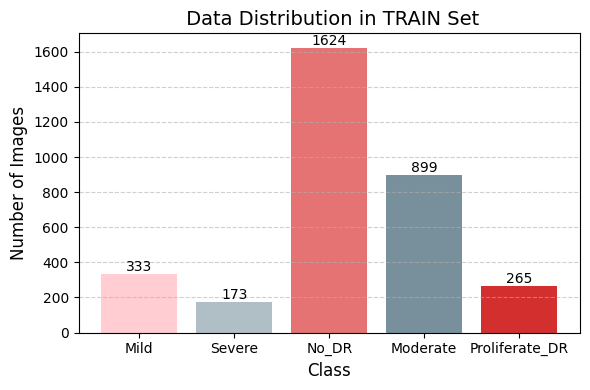

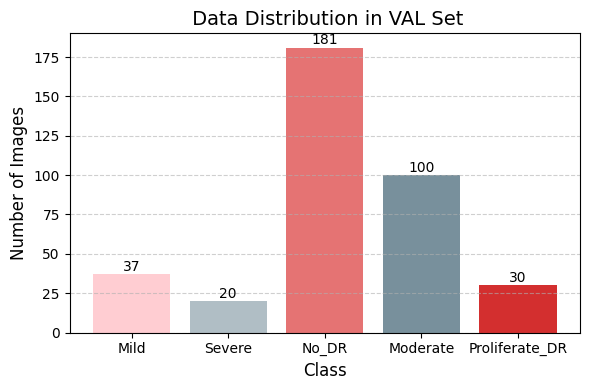

In [6]:
import matplotlib.pyplot as plt

bar_colors = ['#FFCDD2',
              '#B0BEC5',
              '#E57373',
              '#78909C',
              '#D32F2F']

# Display data distribution as a bar chart for train and validation sets
for split in ['train', 'val']:
    plt.figure(figsize=(6, 4))
    class_names = list(folders[split].keys())
    counts = list(folders[split].values())

    # Assign color to each class
    colors = [bar_colors[i % len(bar_colors)] for i in range(len(class_names))]

    # Create the bar chart
    bars = plt.bar(class_names, counts, color=colors)

    # Add count labels
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.1, int(yval), ha='center', va='bottom')

    plt.title(f" Data Distribution in {split.upper()} Set", fontsize=14)
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


## 4. Create TensorFlow Datasets with Data Augmentation

Found 3294 files belonging to 5 classes.
Found 368 files belonging to 5 classes.


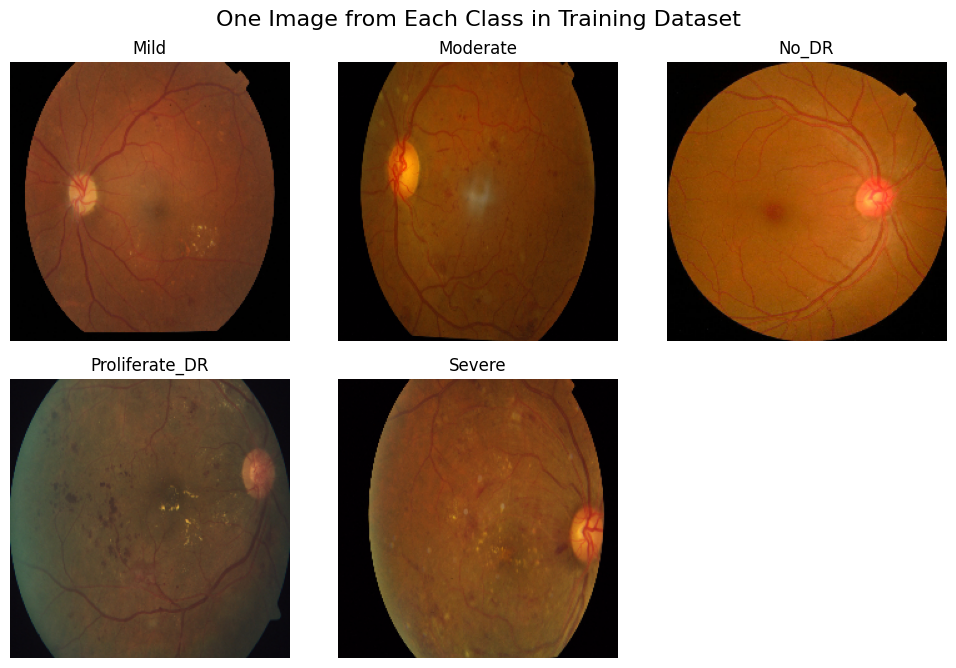

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Parameters
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

OUTPUT_PATH = "/kaggle/working/MyNewDataSplit"
train_dir = os.path.join(OUTPUT_PATH, 'train')
val_dir   = os.path.join(OUTPUT_PATH, 'val')

# Load datasets
train_ds = image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_ds = image_dataset_from_directory(
    val_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Visualize one non-duplicate image from each class in the training dataset
plt.figure(figsize=(10, 10))
class_names = train_ds.class_names

for i, class_name in enumerate(class_names):
    class_folder_path = os.path.join(train_dir, class_name)
    class_images = os.listdir(class_folder_path)

    # Filter out duplicated images
    original_images = [img for img in class_images if '_dup' not in img]

    # Fallback to any image if all are duplicates (edge case)
    chosen_image = original_images[0] if original_images else class_images[0]

    image_path = os.path.join(class_folder_path, chosen_image)
    image = plt.imread(image_path)

    # Display the image
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

# Add overall title
plt.suptitle("One Image from Each Class in Training Dataset", fontsize=16)
plt.tight_layout()
plt.show()


Found 3294 files belonging to 5 classes.
Found 368 files belonging to 5 classes.


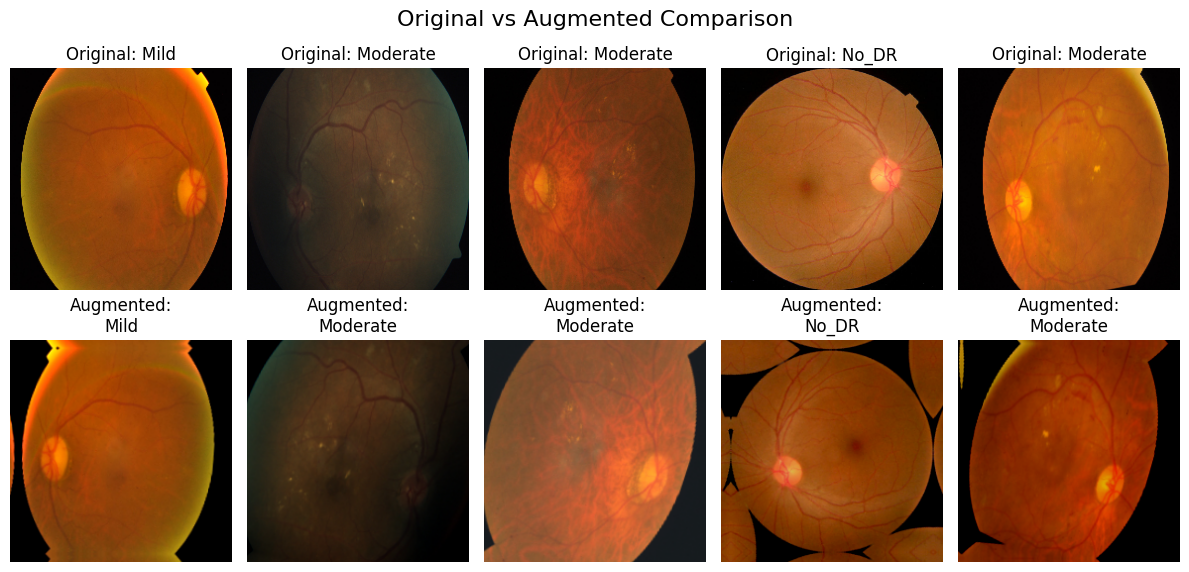

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
import numpy as np

# Load the dataset from directories
train_ds = image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_ds = image_dataset_from_directory(
    val_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Define data augmentation pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(factor=0.2),
])

# Retrieve class names directly from train_ds
class_names = train_ds.class_names

# Prefetch datasets to optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

sample_images, sample_labels = next(iter(train_ds))

plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].numpy().astype("uint8"))
    label_index = np.argmax(sample_labels[i].numpy())
    plt.title(f"Original: {class_names[label_index]}")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    augmented = data_augmentation(sample_images[i:i+1])
    plt.imshow(augmented[0].numpy().astype("uint8"))
    plt.title(f"Augmented:\n{class_names[label_index]}")
    plt.axis("off")

plt.suptitle("Original vs Augmented Comparison", fontsize=16)
plt.tight_layout()
plt.show()


## 5. Define the Models

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

def recall_m(y_true, y_pred):
    true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
    possible_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + tf.keras.backend.epsilon())

def precision_m(y_true, y_pred):
    true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
    predicted_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_pred, 0, 1)))
    return true_positives / (predicted_positives + tf.keras.backend.epsilon())

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+tf.keras.backend.epsilon()))

# Image Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(OUTPUT_PATH, "train"),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = train_datagen.flow_from_directory(
    os.path.join(OUTPUT_PATH, "val"),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

def depthwise_separable_conv(inputs, filters, strides=1, use_se=True):
    """Depthwise Separable Convolution with optional SE block."""
    x = layers.DepthwiseConv2D(kernel_size=3, strides=strides, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, kernel_size=1, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    if use_se:
        x = squeeze_excitation_block(x)

    return x

def squeeze_excitation_block(inputs, ratio=16):
    """Squeeze-and-Excitation block to improve feature importance learning."""
    filters = inputs.shape[-1]
    x = layers.GlobalAveragePooling2D()(inputs)
    x = layers.Dense(filters // ratio, activation='relu')(x)
    x = layers.Dense(filters, activation='sigmoid')(x)
    x = layers.Reshape((1, 1, filters))(x)
    return layers.Multiply()([inputs, x])

def build_model(input_shape=(224, 224, 3), num_classes=5):
    inputs = layers.Input(shape=input_shape)

    # Initial Standard Convolution
    x = layers.Conv2D(32, kernel_size=3, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Depthwise Separable Blocks with SE
    x = depthwise_separable_conv(x, 64, strides=1, use_se=True)
    x = depthwise_separable_conv(x, 128, strides=2, use_se=True)
    x = depthwise_separable_conv(x, 128, strides=1, use_se=True)
    x = depthwise_separable_conv(x, 256, strides=2, use_se=True)
    x = depthwise_separable_conv(x, 256, strides=1, use_se=True)
    x = depthwise_separable_conv(x, 512, strides=2, use_se=True)
    x = depthwise_separable_conv(x, 512, strides=1, use_se=True)
    x = depthwise_separable_conv(x, 1024, strides=2, use_se=True)
    x = depthwise_separable_conv(x, 1024, strides=1, use_se=True)

    # Global Average Pooling and Fully Connected Layer
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

def load_pretrained_model(base_model_fn, preprocess_input_fn, model_name, input_shape=(224, 224, 3), num_classes=5):
    base_model = base_model_fn(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False  # Freeze the base model

    inputs = keras.Input(shape=input_shape)
    x = preprocess_input_fn(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name=model_name)

from sklearn.utils import class_weight
import numpy as np

train_labels = train_generator.classes

train_labels_np = np.array(train_labels)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_np),
    y=train_labels_np
)

# Convert to dict
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

strategy = tf.distribute.get_strategy()
with strategy.scope():
    models_dict = {
        "DenseNet121": load_pretrained_model(
            tf.keras.applications.DenseNet121,
            tf.keras.applications.densenet.preprocess_input,
            "DenseNet121"
        ),
        "ResNet50": load_pretrained_model(
            tf.keras.applications.ResNet50,
            tf.keras.applications.resnet50.preprocess_input,
            "ResNet50"
        ),
        "EfficientNetB0": load_pretrained_model(
            tf.keras.applications.EfficientNetB0,
            tf.keras.applications.efficientnet.preprocess_input,
            "EfficientNetB0"
        ),
        "Custom_SE_CNN": build_model()
    }


# Display model summaries
for name, model in models_dict.items():
    print(f"\n--- {name} Summary ---")
    model.summary()


Found 3294 images belonging to 5 classes.
Found 368 images belonging to 5 classes.
Class Weights: {0: np.float64(1.9783783783783784), 1: np.float64(0.7328142380422692), 2: np.float64(0.4056650246305419), 3: np.float64(2.4860377358490564), 4: np.float64(3.808092485549133)}
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

--- DenseNet121 Summary ---


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,169,349 (27.35 MB)

 Trainable params: 131,845 (515.02 KB)

...

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │        896 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 112, 112,  │        320 │ re_lu[0][0]       │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      2,112 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │        320 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 112, 112,  │          0 │ re_lu_2[0][0],    │
│                     │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 56, 56,    │        640 │ multiply[0][0]    │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 2,636,985 (10.06 MB)

 Trainable params: 2,623,289 (10.01 MB)

 Non-trainable params: 13,696 (53.50 KB)

## 6. Training Model

In [10]:
EPOCHS = 100
history_dict = {}
results = {}

def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"/kaggle/working/{model_name}_best.keras", monitor="val_loss", save_best_only=True)
    ]

with strategy.scope():
    for name, model in models_dict.items():
        print(f"\n\n=== Training Model: {name} ===")
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss="categorical_crossentropy",
            metrics=[
                "accuracy",
                tf.keras.metrics.Precision(name="precision"),
                tf.keras.metrics.Recall(name="recall"),
                tf.keras.metrics.AUC(name="auc")
            ]
        )
        h = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            class_weight=class_weights_dict,
            callbacks=get_callbacks(name),
            verbose=1
        )
        history_dict[name] = h.history

        # Evaluate model
        # Inside the training loop
        test_metrics = model.evaluate(val_ds, verbose=0)
        results[name] = {
            "val_loss": test_metrics[0],
            "val_accuracy": test_metrics[1],
            "val_precision": test_metrics[2],
            "val_recall": test_metrics[3],
            "val_auc": test_metrics[4]
        }




=== Training Model: DenseNet121 ===
Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 80s 474ms/step - accuracy: 0.2489 - auc: 0.5559 - loss: 1.9534 - precision: 0.2911 - recall: 0.1032 - val_accuracy: 0.6332 - val_auc: 0.8871 - val_loss: 1.1500 - val_precision: 0.9846 - val_recall: 0.1739
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.5153 - auc: 0.7945 - loss: 1.4457 - precision: 0.7922 - recall: 0.2190 - val_accuracy: 0.6875 - val_auc: 0.9200 - val_loss: 1.0051 - val_precision: 0.9837 - val_recall: 0.3288
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.5641 - auc: 0.8459 - loss: 1.3085 - precision: 0.8621 - recall: 0.3010 - val_accuracy: 0.6902 - val_auc: 0.9250 - val_loss: 0.9374 - val_precision: 0.9790 - val_recall: 0.3804
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.5813 - auc: 0.8596 - loss: 1.2678 - precision: 0.8735 - recall: 0.3622 - val_accuracy: 0.6957 - val_auc: 0.9273 - val_loss: 0.9081 - val_precision: 0.9728 -

## 7. Ensemble Model

In [11]:
import tensorflow as tf
import numpy as np

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images',
    image_size=(224, 224),
    batch_size=32,
    label_mode="int"
)

X_val = []
y_val = []

for images, labels in validation_dataset:
    X_val.append(images.numpy())
    y_val.append(labels.numpy())

X_val = np.concatenate(X_val, axis=0)
y_val = np.concatenate(y_val, axis=0)

validation_data = X_val
validation_labels = y_val


Found 3662 files belonging to 5 classes.


In [12]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

validation_data = X_val
validation_labels = y_val

ensemble_probs_list = []

for model_name, model in models_dict.items():
    print(f"Predicting with {model_name}...")
    probs = model.predict(validation_data, verbose=0)
    ensemble_probs_list.append(probs)

ensemble_probs = np.mean(ensemble_probs_list, axis=0)

ensemble_preds = np.argmax(ensemble_probs, axis=1)

cm_ensemble = confusion_matrix(validation_labels, ensemble_preds)
report_ensemble = classification_report(validation_labels, ensemble_preds, target_names=class_names)

print("\n Ensemble Classification Report:\n", report_ensemble)


Predicting with DenseNet121...
Predicting with ResNet50...
Predicting with EfficientNetB0...
Predicting with Custom_SE_CNN...

 Ensemble Classification Report:
                 precision    recall  f1-score   support

          Mild       0.82      0.95      0.88       370
      Moderate       0.96      0.90      0.93       999
         No_DR       0.99      0.98      0.99      1805
Proliferate_DR       0.88      0.90      0.89       295
        Severe       0.85      0.94      0.89       193

      accuracy                           0.95      3662
     macro avg       0.90      0.93      0.92      3662
  weighted avg       0.95      0.95      0.95      3662



## 8. Visualization & Evaluation

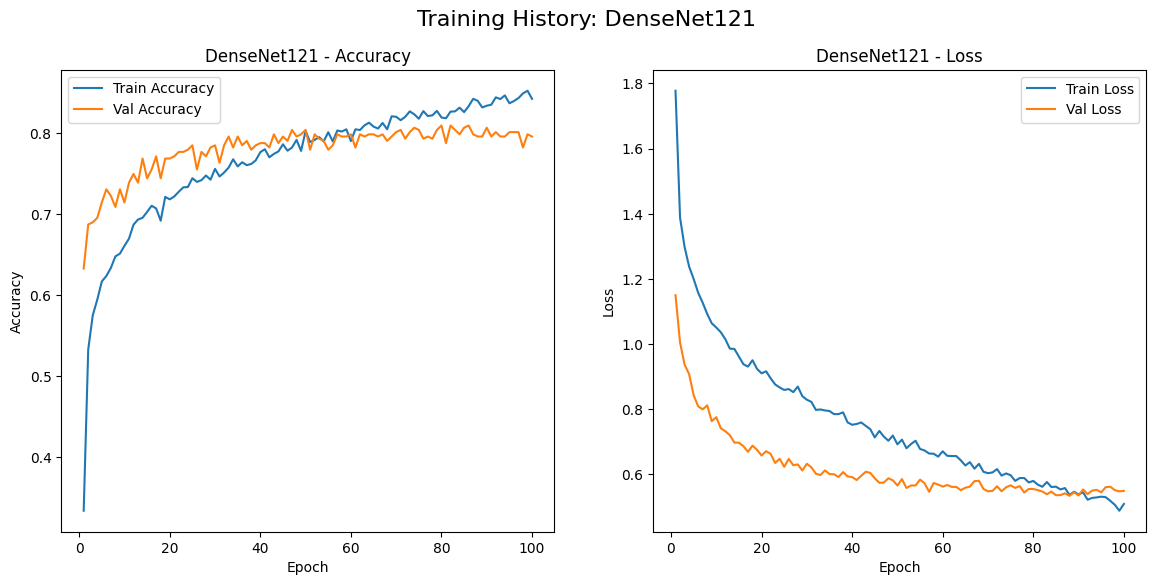

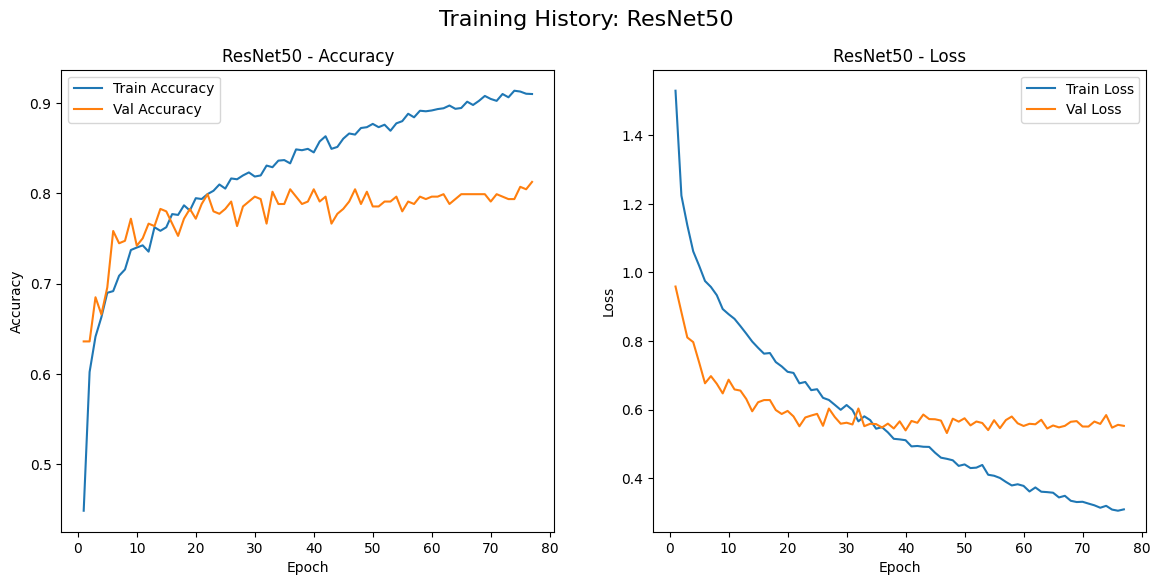

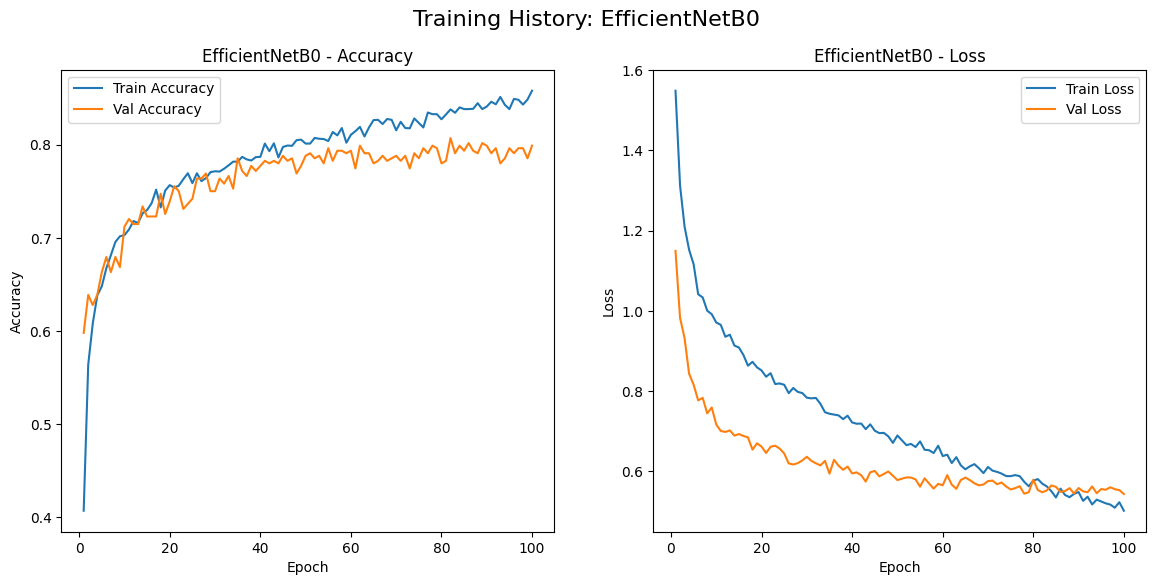

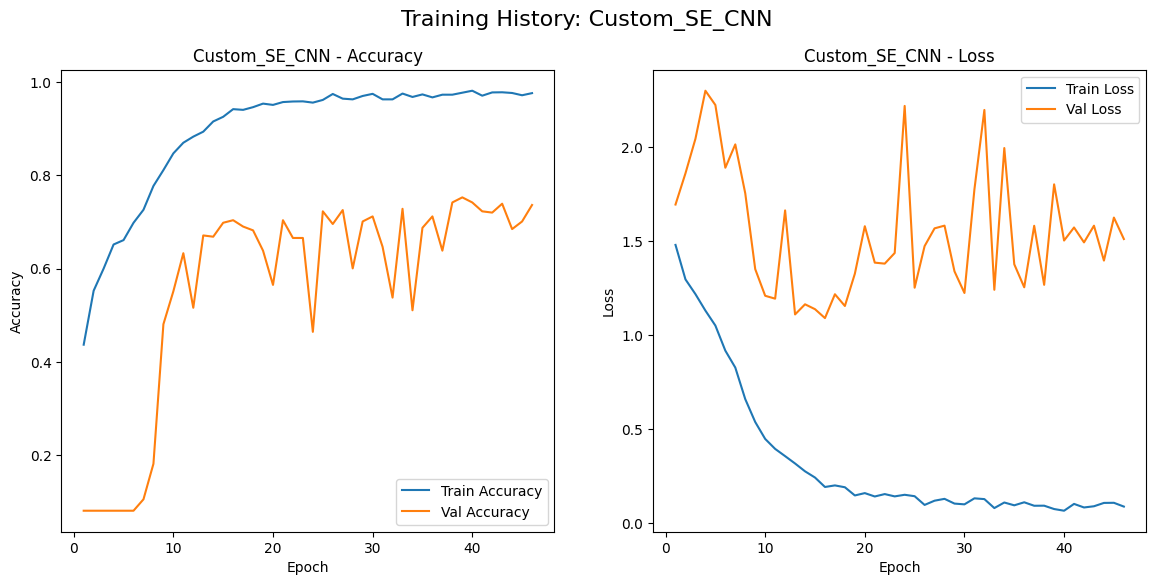

In [13]:
# 8.1 Plot Training History (Accuracy & Loss) of all models
for name, history in history_dict.items():
    epochs_range = range(1, len(history["accuracy"]) + 1)
    plt.figure(figsize=(14,6))

    # Plot Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs_range, history["accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_accuracy"], label="Val Accuracy")
    plt.title(f"{name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Plot Loss
    plt.subplot(1,2,2)
    plt.plot(epochs_range, history["loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Val Loss")
    plt.title(f"{name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.suptitle(f"Training History: {name}", fontsize=16)
    plt.show()

Found 3662 files belonging to 5 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━

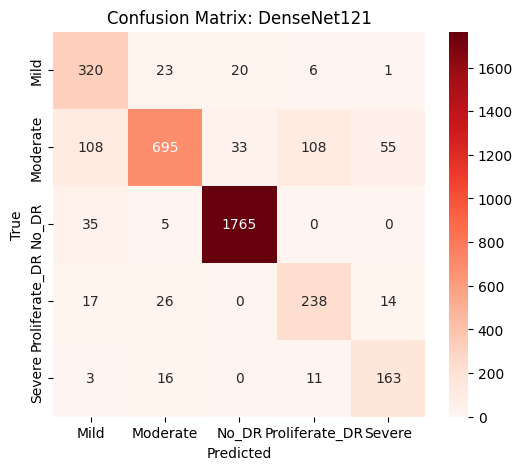

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

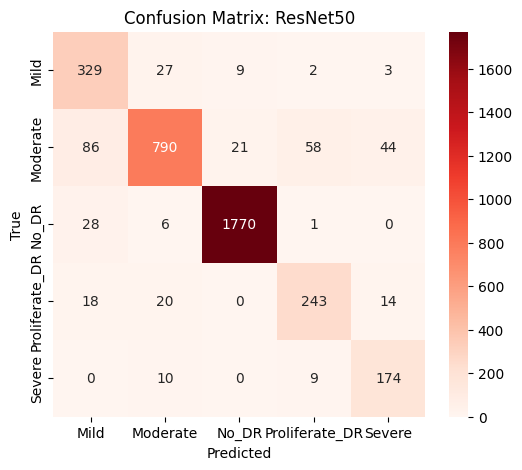

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 

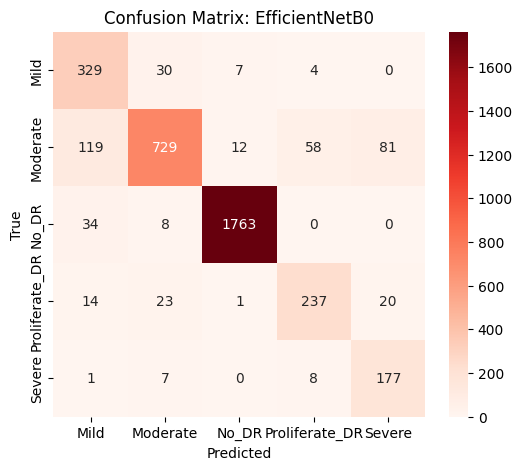

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━

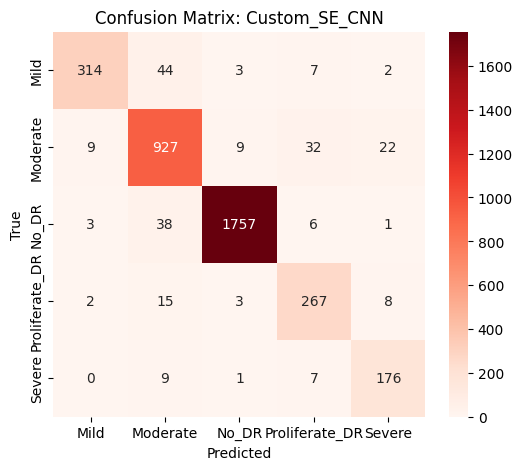

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Load validation data
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/kaggle/input/diabetic-retinopathy-224x224-2019-data/colored_images',
    image_size=(224, 224),
    batch_size=32,
    label_mode="int"
)

def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    plt.figure(figsize=(6,5))

    cmap = sns.color_palette("Reds", as_cmap=True)

    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

for name, model in models_dict.items():
    y_true_model = []
    y_pred_model = []

    for images, labels in validation_dataset:
        preds = model.predict(images)
        y_true_model.extend(labels.numpy())
        y_pred_model.extend(np.argmax(preds, axis=1))

    cm_model = confusion_matrix(y_true_model, y_pred_model)

    plot_confusion_matrix(cm_model, class_names, title=f"Confusion Matrix: {name}")


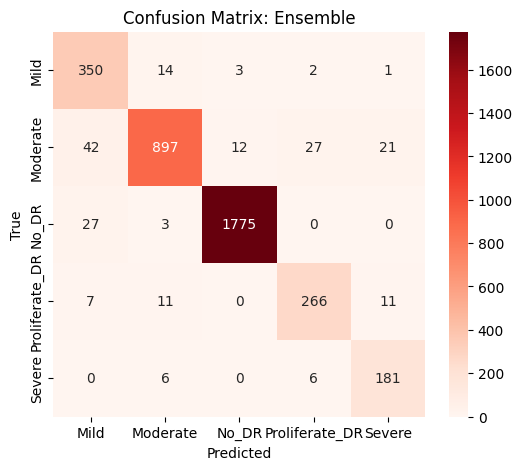

In [15]:
ensemble_preds = np.argmax(ensemble_probs, axis=1)
y_true_val = validation_labels

cm_ensemble = confusion_matrix(y_true_val, ensemble_preds)

plot_confusion_matrix(cm_ensemble, class_names, title="Confusion Matrix: Ensemble")

In [16]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, log_loss
from tensorflow.keras.utils import to_categorical
import numpy as np

true_labels = validation_labels
n_classes = ensemble_probs.shape[1]

true_onehot = to_categorical(true_labels, num_classes=n_classes)

pred_probs = ensemble_probs
ensemble_preds = np.argmax(pred_probs, axis=1)

ensemble_precision = precision_score(true_labels, ensemble_preds, average='weighted', zero_division=0)
ensemble_recall = recall_score(true_labels, ensemble_preds, average='weighted', zero_division=0)
ensemble_auc = roc_auc_score(true_onehot, pred_probs, multi_class='ovr')  # AUC for multiclass
ensemble_loss = log_loss(true_onehot, pred_probs)  # Cross-entropy loss

print(f"Ensemble Precision: {ensemble_precision:.4f}")
print(f"Ensemble Recall:    {ensemble_recall:.4f}")
print(f"Ensemble AUC:       {ensemble_auc:.4f}")
print(f"Ensemble Log Loss:  {ensemble_loss:.4f}")


Ensemble Precision: 0.9504
Ensemble Recall:    0.9473
Ensemble AUC:       0.9945
Ensemble Log Loss:  0.2662


Validation Set Evaluation Results for Each Model:


,val_accuracy,val_loss,val_precision,val_recall,val_auc
DenseNet121,0.796196,0.534434,0.867314,0.728261,0.963862
ResNet50,0.804348,0.531531,0.854938,0.752717,0.963326
EfficientNetB0,0.798913,0.543683,0.836364,0.750000,0.962053
Custom_SE_CNN,0.703804,1.090873,0.729651,0.682065,0.901064
Ensemble_Model,0.947297,0.266238,0.950387,0.947297,0.994460


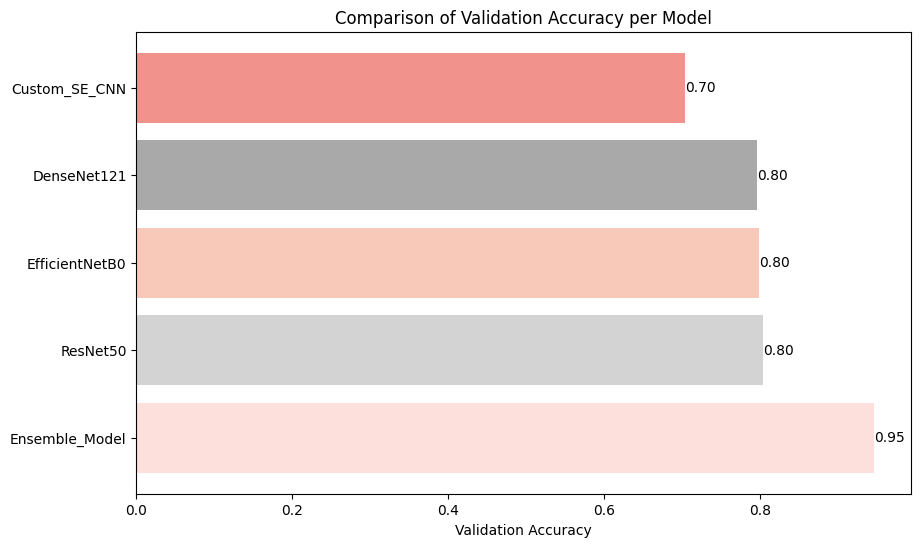

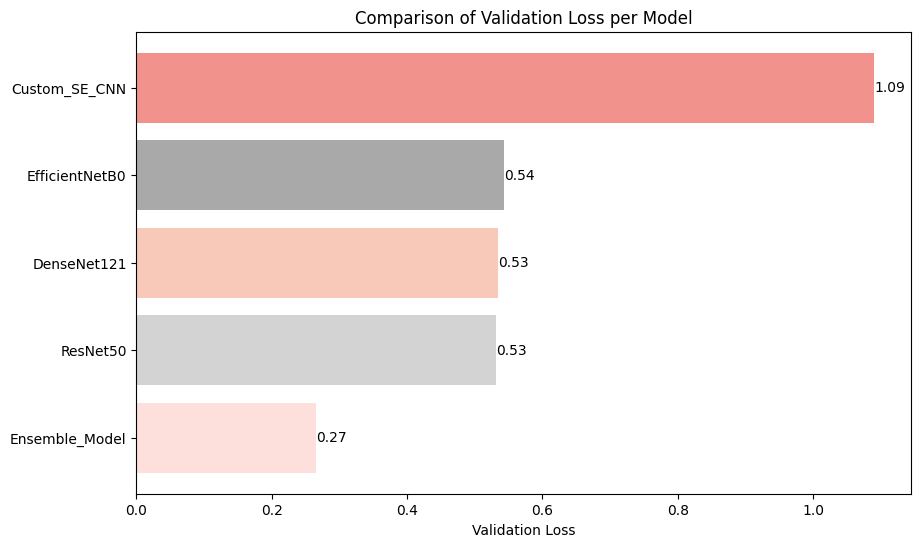

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

red_shades = ['#FDE0DC', '#F8C8B8', '#F1928C', '#D94F38', '#9B1B13']
grey_shades = ['#D3D3D3', '#A9A9A9', '#808080', '#585858', '#333333']

colors = []
for i in range(len(red_shades)):
    colors.append(red_shades[i])
    colors.append(grey_shades[i])
from sklearn.metrics import accuracy_score

ensemble_accuracy = accuracy_score(true_labels, ensemble_preds)

results_df = pd.DataFrame(results).T
results_df = results_df[['val_accuracy', 'val_loss', 'val_precision', 'val_recall', 'val_auc']]

results_df.loc["Ensemble_Model"] = {
    "val_accuracy": ensemble_accuracy,
    "val_loss": ensemble_loss,
    "val_precision": ensemble_precision,
    "val_recall": ensemble_recall,
    "val_auc": ensemble_auc
}

print("Validation Set Evaluation Results for Each Model:")
display(results_df)

results_df_sorted = results_df.sort_values(by="val_accuracy", ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.barh(results_df_sorted.index, results_df_sorted["val_accuracy"], color=colors[:len(results_df_sorted)])
plt.xlabel("Validation Accuracy")
plt.title("Comparison of Validation Accuracy per Model")

for bar in bars:
    width = bar.get_width()
    label_text = f'{width:.2f}'
    plt.text(width, bar.get_y() + bar.get_height()/2, label_text, ha='left', va='center')

plt.show()

results_df_sorted_loss = results_df.sort_values(by="val_loss", ascending=True)  # Sort by ascending loss
plt.figure(figsize=(10, 6))
bars = plt.barh(results_df_sorted_loss.index, results_df_sorted_loss["val_loss"], color=colors[:len(results_df_sorted_loss)])
plt.xlabel("Validation Loss")
plt.title("Comparison of Validation Loss per Model")

for bar in bars:
    width = bar.get_width()
    label_text = f'{width:.2f}'
    plt.text(width, bar.get_y() + bar.get_height()/2, label_text, ha='left', va='center')

plt.show()


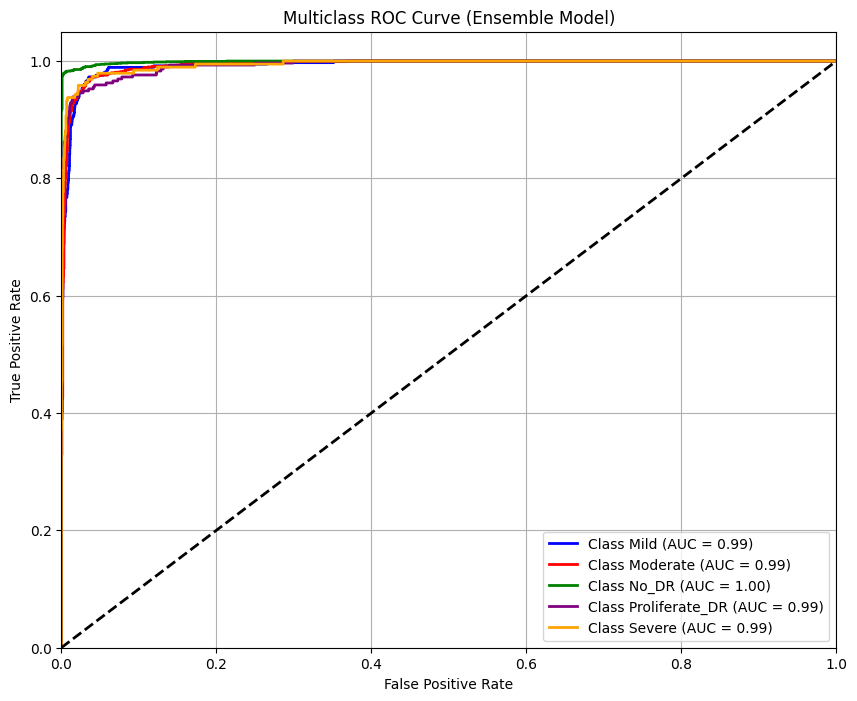

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle


n_classes = len(class_names)
y_true_bin = label_binarize(validation_labels, classes=range(n_classes))
y_score_ensemble = ensemble_probs

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'purple', 'orange', 'cyan', 'magenta', 'brown'])

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score_ensemble[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (Ensemble Model)')
plt.legend(loc="lower right")
plt.grid()
plt.show()
